In [ ]:
import torch
from torch import nn as nn
import math
from glob import glob
from torchsummary import summary
from torch_snippets import *
from torch_snippets.torch_loader import Report
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.manifold import TSNE
import umap
from collections import defaultdict
import seaborn as sns


#is GPU available?
gpu = torch.cuda.is_available()

#defining device where to to the computation
device = torch.device(0) if gpu else torch.device('cpu')

2026-02-14 17:31:09.898588: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-14 17:31:09.910574: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-14 17:31:09.914256: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-14 17:31:09.923470: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Randomly split a fileset into training, validation, and test sets: output lists of image names

In [ ]:
# Set the folder with the samples (images) that compose a dataset and the number of classes

orig_dir   = './images/corel'
nclasses   = 6

# Set the desired image size for rescaling and maximum value for normalization

width       = 224
height      = 224
nchannels   = 3
maxval      = 255.
input_shape = (nchannels,height,width)

# Set the percentages of samples that will be used for training, validation and test.

train_perc = 0.40
valid_perc = 0.30
test_perc  = 0.30

# Create training, validation, and test sets.

data = glob(orig_dir+"/*.png") # it returns a list of image filenames

num_train_samples = int(len(data)*train_perc)
num_valid_samples = int(len(data)*valid_perc)
num_test_samples  = len(data) - num_train_samples - num_valid_samples
np.random.shuffle(data) # randomly change the order of the filenames in data
trainset = data[:num_train_samples]
validset = data[num_train_samples:num_train_samples+num_valid_samples]
testset  = data[num_train_samples+num_valid_samples:]

# Set output model name

model_name  = 'CorelCNN.pth'

### Create image datasets with some preprocessing: output a list of image tensors

In [ ]:
# Regular preprocessing transformation. The input is a PIL image, which after being resized,
# it is converted into a tensor for normalization using the ImageNet mean and stdev parameters.

# agora nesse exemplo estamos usando DATA AUGMENTATION
prep = transforms.Compose([
    transforms.Resize((224,224), interpolation=transforms.InterpolationMode.BILINEAR,
                      max_size=None, antialias=True),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Such transformations are applied everytime images are loaded from the filename lists in training, validation,
# and test sets. We will do that during training, then by adding affine transformations and increasing the number
# of epochs, we are actually implementing data augmentation.

aug = transforms.Compose([
    transforms.Resize((300,300), interpolation=transforms.InterpolationMode.BILINEAR,
                      max_size=None, antialias=True),
    transforms.RandomAffine(degrees=10, translate=(0.05,0.10), scale=(0.9,1.1), shear=(-2,2),
                            interpolation=transforms.InterpolationMode.BILINEAR,
                            fill=0),
    transforms.CenterCrop(250),
    transforms.Resize((224,224), interpolation=transforms.InterpolationMode.BILINEAR,
                      max_size=None, antialias=True),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Create an image dataset by applying one of the preprocessing transformations above

class ImageDataset(): # there are three mandatory functions: init, len, getitem
    def __init__(self, dataset, transform=None):
        # it gets the image true labels and set the preprocessing transformation
        self.dataset   = dataset
        self.targets   = [int(str(x).split("/")[-1].split("_")[0])-1 for x in self.dataset]#pegar onumero da classe
        self.transform = transform
    def __len__(self): return len(self.dataset)
    def __getitem__(self, ix): # returns the item at position ix
        filename = self.dataset[ix]
        target   = self.targets[ix]
        image    = Image.open(filename) # It is a PIL image
        if (self.transform is not None):
            image = self.transform(image) #convertendo pra tensor e ai precisa da permutacao pq o numpy nao coloca direto
        else: # just reshape the image as a tensor with nchannels, height, width
            image = torch.from_numpy(np.array(image)).permute(2,0,1).float()
        return(image,target)

In [ ]:
#vetores de tensores
#tensor de todo o dataset e o tensor do grao da imagem qual classe que ela esta
trainset = ImageDataset(trainset, aug) # verify the difference with and wothout data augmentation
validset = ImageDataset(validset, prep)
testset  = ImageDataset(testset, prep)

### Visualize selected images

Number of images: 142
Images are 224x224x3
Class of the image:  5


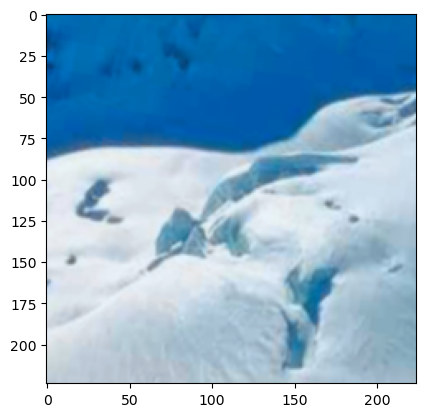

In [ ]:
# visualize images from the trainset

print("Number of images:", len(trainset))
image, target = trainset[100] # it executes getitem
image     = image.permute(1,2,0).numpy()
image     = 255*(image - np.min(image))/(np.max(image)-np.min(image))
image     = image.astype('uint8')
print("Images are {}x{}x{}".format(width,height,nchannels))
plt.imshow(image)
print("Class of the image: ", target+1)
plt.show()

### Generate batches with batchsize images at random

In [ ]:
batchsize = 32 #vai quebrar o vetor de tensores embaralhar e criar em grupos de 32 imagens e é tudo ponteiro de funcao
trainload = DataLoader(trainset, batch_size=batchsize, shuffle=True)
testload  = DataLoader(testset, batch_size=batchsize, shuffle=True)
validload = DataLoader(validset, batch_size=batchsize, shuffle=True)

next(iter(trainload)) # inspect next item in the trainload

[tensor([[[[ 2.0092,  2.0092,  2.0263,  ...,  1.3755,  1.3755,  1.3413],
           [ 2.0092,  2.0092,  2.0263,  ...,  1.3927,  1.3755,  1.3413],
           [ 2.0092,  2.0092,  2.0263,  ...,  1.3927,  1.3927,  1.3927],
           ...,
           [-1.1589, -1.1247, -1.0562,  ..., -0.0972, -0.1657, -0.2171],
           [-1.2103, -1.1760, -1.1075,  ..., -0.0801, -0.1143, -0.1486],
           [-1.2274, -1.1760, -1.1418,  ..., -0.1314, -0.0801, -0.0972]],
 
          [[-1.0903, -1.0903, -1.0553,  ..., -1.2304, -1.2479, -1.2654],
           [-1.0903, -1.0903, -1.0553,  ..., -1.2304, -1.2479, -1.3004],
           [-1.0728, -1.0728, -1.0553,  ..., -1.2654, -1.2654, -1.2829],
           ...,
           [-1.3529, -1.3354, -1.2654,  ..., -0.7927, -0.8627, -0.8978],
           [-1.3354, -1.3179, -1.2654,  ..., -0.7402, -0.7752, -0.8102],
           [-1.3004, -1.3179, -1.2654,  ..., -0.7227, -0.6877, -0.7227]],
 
          [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
           [-

### ConvNet model

In [ ]:
# a convolutional block
def conv_block(nchannels_in, nchannels_out, stride_val):
    return nn.Sequential(
        #defining convolutional layer
        nn.Conv2d(in_channels=nchannels_in, out_channels=nchannels_out, kernel_size=(5, 5),
                  stride=1, padding=2, bias=False),
        #defining a batch normalization layer, which dismisses the need for bias in the previous conv layer
        nn.BatchNorm2d(num_features=nchannels_out),
        #defining activation layer
        nn.ReLU(),
        #defining a pooling layer
        nn.MaxPool2d(kernel_size=(3, 3), stride=stride_val, padding=1)
    )

# extrator dela vai entrar o numero de canais input_shape numero de canais de entrada 32, depois entra 32 sai 256, a imagem era 224 e agora e 256
class CorelNet(nn.Module):

    def __init__(self, input_shape, num_classes):
        super(CorelNet, self).__init__()

        #defining feature extractor
        self.features = nn.Sequential(
            conv_block(input_shape[0],32,2),
            conv_block(32,256,2)
        )

        #defining classifier
        self.classifier = nn.Sequential(
            nn.Linear(in_features=(input_shape[1]//4)*(input_shape[2]//4)*256, out_features=64, bias=True),
            #nn.Dropout(0.20), #aqui input sahpe 1 é largura, input_shpae é a altura dividindo por 4 e multiplicando por 256
            nn.ReLU(),
            nn.Linear(64, nclasses)
        )

        #initialize weights
        self._initialize_weights()

    def forward(self, x):
       #extracts features
        x = self.features(x)

        #transforms outputs into a 2D tensor
        x = torch.flatten(x, start_dim=1)

        #classifies features
        y = self.classifier(x)

        return y

    def _initialize_weights(self):
        #for each submodule of our network
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                #get the number of elements in the layer weights
                n = m.kernel_size[0] * m.kernel_size[1] * m.in_channels
                #initialize layer weights with random values generated from a normal
                #distribution with mean = 0 and std = sqrt(2. / n))
                m.weight.data.normal_(mean=0, std=math.sqrt(2. / n))

                if m.bias is not None:
                    #initialize bias with 0
                    m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                #initialize layer weights with random values generated from a normal
                #distribution with mean = 0 and std = 1/100
                m.weight.data.normal_(mean=0, std=0.01)
                if m.bias is not None:
                #initialize bias with 0
                    m.bias.data.zero_()

### Create the model

In [ ]:
model = CorelNet(input_shape, nclasses).to(device)
summary(model,input_shape)
#arquitetura da rede

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 256, 56, 56]         --
|    └─Sequential: 2-1                   [-1, 32, 112, 112]        --
|    |    └─Conv2d: 3-1                  [-1, 32, 224, 224]        2,400
|    |    └─BatchNorm2d: 3-2             [-1, 32, 224, 224]        64
|    |    └─ReLU: 3-3                    [-1, 32, 224, 224]        --
|    |    └─MaxPool2d: 3-4               [-1, 32, 112, 112]        --
|    └─Sequential: 2-2                   [-1, 256, 56, 56]         --
|    |    └─Conv2d: 3-5                  [-1, 256, 112, 112]       204,800
|    |    └─BatchNorm2d: 3-6             [-1, 256, 112, 112]       512
|    |    └─ReLU: 3-7                    [-1, 256, 112, 112]       --
|    |    └─MaxPool2d: 3-8               [-1, 256, 56, 56]         --
├─Sequential: 1-2                        [-1, 6]                   --
|    └─Linear: 2-3                       [-1, 64]                  51,380,28

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 256, 56, 56]         --
|    └─Sequential: 2-1                   [-1, 32, 112, 112]        --
|    |    └─Conv2d: 3-1                  [-1, 32, 224, 224]        2,400
|    |    └─BatchNorm2d: 3-2             [-1, 32, 224, 224]        64
|    |    └─ReLU: 3-3                    [-1, 32, 224, 224]        --
|    |    └─MaxPool2d: 3-4               [-1, 32, 112, 112]        --
|    └─Sequential: 2-2                   [-1, 256, 56, 56]         --
|    |    └─Conv2d: 3-5                  [-1, 256, 112, 112]       204,800
|    |    └─BatchNorm2d: 3-6             [-1, 256, 112, 112]       512
|    |    └─ReLU: 3-7                    [-1, 256, 112, 112]       --
|    |    └─MaxPool2d: 3-8               [-1, 256, 56, 56]         --
├─Sequential: 1-2                        [-1, 6]                   --
|    └─Linear: 2-3                       [-1, 64]                  51,380,28

### Define the loss function with L2 regularization

In [ ]:
def Criterion(model, preds, targets):
    ce            = nn.CrossEntropyLoss().to(device)
    loss          = ce(preds, targets.long())
    # add l2_regularization
    l2_regularization = 0
    for param in model.parameters():
        l2_regularization += torch.norm(param,2)
    loss += 0.0001*l2_regularization # 0.0001 is the weight_decay
    # compute mean accuracy in the batch
    pred_labels   = torch.max(preds, 1)[1] # same as argmax
    acc           = torch.sum(pred_labels == targets.data)
    n             = pred_labels.size(0)
    acc           = acc/n
    return loss, acc


criterion = Criterion

### Define optimizer and learning scheduler

In [ ]:
optimizer    = optim.Adam(model.parameters(), lr=1e-5)
# gamma=0.9 is a multiplicative factor for lr decay at every epoch
# lr_scheduler = optim.lr_scheduler.ExponentialLR(optimizer, 0.9)
# gamma=0.9 is a multiplicative factor for lr decay at every step_size=number of epochs
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.9)

### Clean up memory if needed

In [ ]:
import gc
#del trainset, validset, testset
gc.collect()
torch.cuda.empty_cache()

### Define training and validation functions

In [ ]:
def train_batch(model, data, optimizer, criterion, device):
    model.train()
    ims, targets = data
    ims     = ims.to(device=device)
    targets = targets.to(device=device)
    preds   = model(ims)
    loss, acc = criterion(model, preds, targets)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return loss.item(), acc.item()

@torch.no_grad()
def validate_batch(model, data, criterion, device):
    model.eval()
    ims, targets = data
    ims     = ims.to(device=device)
    targets = targets.to(device=device)
    preds   = model(ims)
    loss, acc = criterion(model, preds, targets)
    return loss.item(), acc.item()

### Train the model and report the results

In [ ]:
# initializing variables
n_epochs = 100
log      = Report(n_epochs)

# starting training and validation
for ex in range(n_epochs):
    N = len(trainload)
    for bx, data in enumerate(trainload):
        loss, acc = train_batch(model, data, optimizer, criterion, device)
        #report results for the batch
        log.record((ex+(bx+1)/N), trn_loss=loss, trn_acc=acc, end='\r')

    N = len(validload)
    for bx, data in enumerate(validload):
        loss, acc = validate_batch(model, data, criterion, device)
        log.record((ex+(bx+1)/N), val_loss=loss, val_acc=acc, end='\r')

    if (ex+1)%10==0: log.report_avgs(ex+1)
    #count epochs for auto-adjusting the learning rate
    lr_scheduler.step()

EPOCH: 10.000  trn_loss: 0.375  val_acc: 0.833  trn_acc: 0.909  val_loss: 0.415  (22.09s - 198.81s remaining)
EPOCH: 20.000  trn_loss: 0.165  val_acc: 0.913  trn_acc: 0.981  val_loss: 0.258  (43.56s - 174.23s remaining)
EPOCH: 30.000  trn_loss: 0.106  val_acc: 0.913  trn_acc: 0.988  val_loss: 0.240  (64.94s - 151.53s remaining)
EPOCH: 40.000  trn_loss: 0.096  val_acc: 0.953  trn_acc: 0.994  val_loss: 0.217  (86.17s - 129.25s remaining)
EPOCH: 50.000  trn_loss: 0.075  val_acc: 0.920  trn_acc: 0.994  val_loss: 0.265  (107.45s - 107.45s remaining)
EPOCH: 60.000  trn_loss: 0.053  val_acc: 0.913  trn_acc: 0.994  val_loss: 0.198  (128.63s - 85.75s remaining)
EPOCH: 70.000  trn_loss: 0.038  val_acc: 0.928  trn_acc: 1.000  val_loss: 0.191  (149.92s - 64.25s remaining)
EPOCH: 80.000  trn_loss: 0.045  val_acc: 0.897  trn_acc: 0.994  val_loss: 0.231  (171.16s - 42.79s remaining)
EPOCH: 90.000  trn_loss: 0.055  val_acc: 0.839  trn_acc: 1.000  val_loss: 0.368  (192.50s - 21.39s remaining)
EPOCH: 10

### Plot the results

100%|██████████████████████████████████████| 201/201 [00:00<00:00, 12303.96it/s]


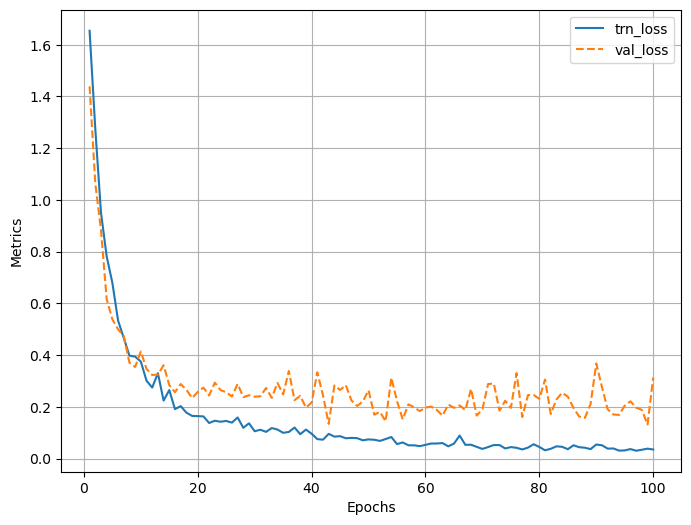

100%|██████████████████████████████████████| 201/201 [00:00<00:00, 12331.68it/s]


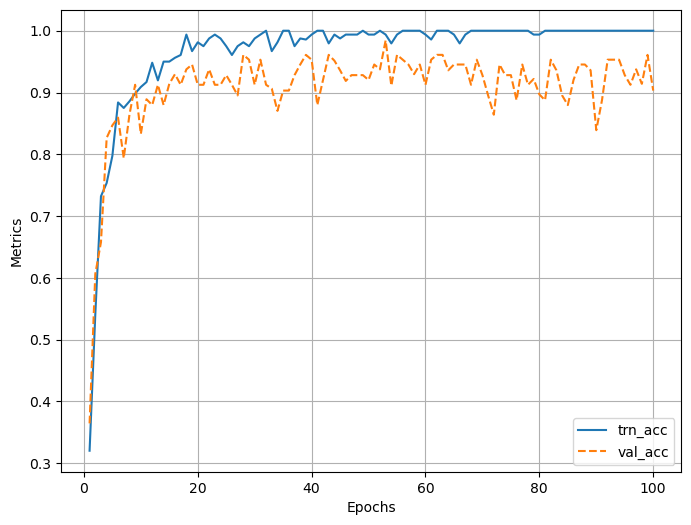

In [ ]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

### Evaluate the model

In [ ]:
def Test(model, testload, criterion, device):
    N = len(testload)
    mean_loss = 0
    mean_acc  = 0
    for bx, data in enumerate(testload):
        loss, acc  = validate_batch(model, data, criterion, device)
        mean_loss += loss
        mean_acc  += acc

    mean_loss = mean_loss / N
    mean_acc  = mean_acc / N
    return(mean_loss, mean_acc)

(loss, acc) = Test(model, testload, criterion, device)
print('Loss: {:.6f} Acc: {:.6f}'.format(loss,acc))

Loss: 0.257625 Acc: 0.914062


### Save the model

In [ ]:
#torch.save(model.to('cpu').state_dict(), model_name)

#### Exercise: Play with optimizers, network architecture and hyperparameters to improve results without underfitting and overfitting. Note that you are using data augmentation, which might requires more epochs and lower learning rates for convergence. Verify preprocessing with no data augmentation and less training samples with data augmentation.

### Visualize activations at the output of the last convolutional block for a given image

In [ ]:
image, target = trainset[100]
image.size()

torch.Size([3, 224, 224])

In [ ]:
image   = image.unsqueeze(0).to(device)

o modelo tem duas classes, classifier e o extrator de caracteristicas

In [ ]:
def get_corelnet_feature_map(model, input_tensor: torch.Tensor) -> torch.Tensor:
    """
    Simple method: Extract feature map by calling model.features directly

    Args:
        model: CorelNet model instance
        input_tensor: Input tensor
    image, target = trainset[100] # it executes getitem
image     = image.permute(1,2,0).numpy()
image     = 255*(image - np.min(image))/(np.max(image)-np.min(image))
image     = image.astype('uint8')
print("Images are {}x{}x{}".format(width,height,nchannels))
plt.imshow(image)
    Returns:
        Feature map from the feature extractor (before flattening)
    """
    model.eval() #em avalicao significa que quando ele executa isso ele economiza memoria, quando ele faz backpropagation ele guarda um grafo, no treino ele tem que calculr os parametros que aprendeu no treino, 1 parametro por batch
    #para poder aplicar depois na iamgem de teste, mas quando coloca em eval ele nao guarda o grafo e nem os parametros e nem o garidente quando usa no_grad, pq aqui estamos avaliando o modelo fazendo um experimento
    with torch.no_grad(): #esse tensor de entrada pode ser uma unica imagem, e se for tem que dar batch de 1 (3 dimensoes (r,g,b) e ai tem que dar um squeeze)
        feature_map = model.features(input_tensor) #se for varias imagens e fez o batch ja pega direto o feature map da saida do extrator com todas as imagens
    return feature_map

In [ ]:
def visualize_corelnet_features(feature_map: torch.Tensor,
                               max_channels: int = 16,
                               start_channel: int = 0,
                               figsize: tuple = (15, 10),
                               sample_idx: int = 0):
    """
    Visualize CorelNet feature maps

    Args:
        feature_map: Feature map tensor (batch_size, channels, height, width)
        max_channels: Maximum number of channels to display
        start_channel: Starting channel index (0-based)
        figsize: Figure size for matplotlib
        sample_idx: Which sample from the batch to visualize
    """
    if feature_map.dim() == 4: #se ja tiver o batch ele faz direto senao ele arruma
        feature_map_sample = feature_map[sample_idx]  # Shape: (channels, height, width)
    else:
        feature_map_sample = feature_map

    total_channels = feature_map_sample.shape[0]
    end_channel = min(start_channel + max_channels, total_channels)
    num_channels = end_channel - start_channel

    if start_channel >= total_channels: #calcula o total de canais
        raise ValueError(f"start_channel ({start_channel}) must be less than total channels ({total_channels})")

    print(f"Feature map shape: {feature_map.shape}")
    print(f"Total channels: {total_channels}")
    print(f"Visualizing channels {start_channel}-{end_channel-1} from sample {sample_idx}")

# se for o starting channel = 0 (canal zero) ele pega os 16 primeiros ativacoes desses canais...

    # Calculate grid dimensions
    cols = 4
    rows = (num_channels + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()

    for i in range(num_channels):
        ax = axes[i]
        channel_idx = start_channel + i
        channel_data = feature_map_sample[channel_idx].cpu().numpy()

        im = ax.imshow(channel_data, cmap='viridis')
        ax.set_title(f'Channel {channel_idx}\nMin: {channel_data.min():.2f}\nMax: {channel_data.max():.2f}',
                    fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.6)

    # Hide unused subplots
    for i in range(num_channels, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f'CorelNet Feature Maps - Channels {start_channel}-{end_channel-1}\nShape: {feature_map.shape}',
                 fontsize=14)
    plt.tight_layout()
    plt.show()

Feature map shape: torch.Size([1, 256, 56, 56])
Total channels: 256
Visualizing channels 32-47 from sample 0


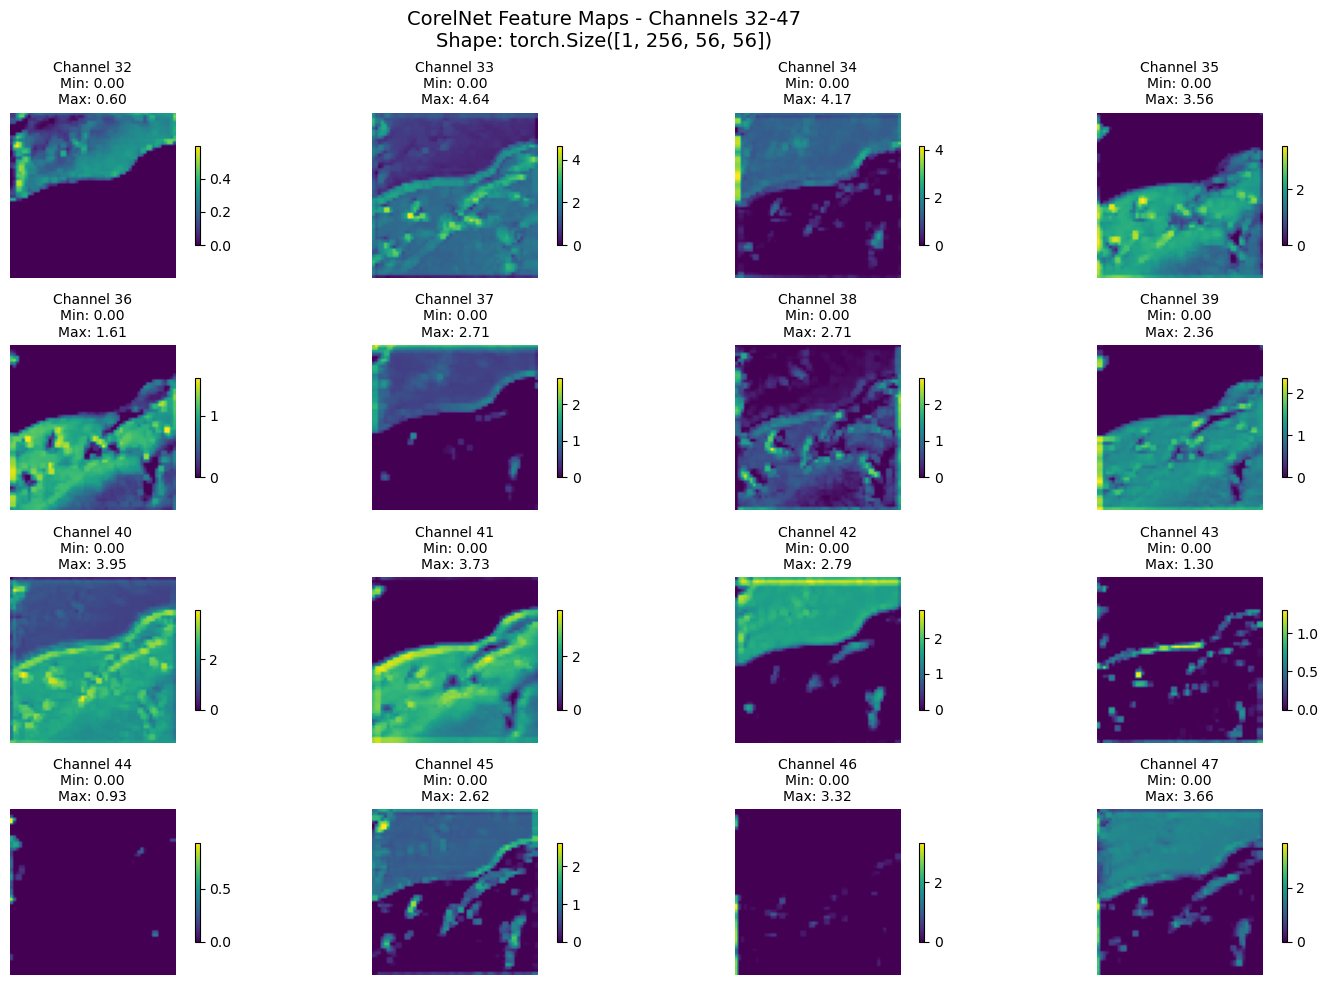

In [ ]:
featmap = get_corelnet_feature_map(model,image)
visualize_corelnet_features(featmap, max_channels=16, start_channel=32)

In [ ]:
class GradCAM: #pega uma unica imagem, passa pela rede, zera os gradientes e calcula o gradiente aassociado a classe da imagem
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        # o modulo do vetor gradientes dos pesos fica maior nos canais que estao associados a classe, e ai usamos o modulo desse vetor
        #gradiente como o peso do canal , se os canais nao forem importantes os canais ficam baixo,
        # e ai fazemos uma soma ponderada e ai vai estar claro onde as regioes cuja ativacao tem maior peso
        # Register hooks: it holds the activation map of the target layer during
        # forward operation and the gradients of the kernels in the backward
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_image, class_idx=None):
        # Forward pass
        model_output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(model_output, dim=1)

        # Zero gradients
        self.model.zero_grad()

        # Backward pass
        class_score = model_output[:, class_idx]
        class_score.backward()

        # Get gradients and activations
        gradients   = self.gradients
        activations = self.activations

        # Calculate weights (global average pooling of gradients)
        # If kernel gradients has shape [batch_size, channels, height, width]
        # e.g., gradients.shape = [1, 64, 28, 28]
        # weights = torch.mean(gradients, dim=[2, 3])
        # weights.shape = [1, 64]
        # The height and width dimensions (28, 28) are averaged out: It then
        # averages the gradients of each kernel creating one weight per kernel. In this case,
        # for a batch of size 1 and 64 kernels, it creates 64 weights

        weights = torch.mean(gradients, dim=[2, 3]) #geramos o mapa de atencao

        # Generate CAM: It is the weighted average of the activation channels using their
        # respective weights
        # cada gradiente tem um peso que e multiplicada pela ativacao e vai dar um mapa de ativacao final
        cam = torch.zeros(activations.shape[2:], dtype=torch.float32).to(device)
        for i, w in enumerate(weights[0]):
            cam += w * activations[0, i, :, :]

        # Apply ReLU: it might be needed when weights are negatives for some kernels. The above
        # and this operation is equivalent to a point-wise convolution followed by activation used
        # in decoders to create saliency maps
        cam = F.relu(cam) #com relu normalizamos a imagem

        # Normalize
        cam = cam - torch.min(cam)
        cam = cam / torch.max(cam)

        return cam.detach().cpu().numpy()

def visualize_gradcam(orig_image, cam, alpha=0.4):
    """
    Overlay GradCAM heatmap on original image
    """
    # Resize CAM to match input image size
    cam_resized = cv2.resize(cam, (orig_image.shape[1], orig_image.shape[0]))

    # Create heatmap, e ai na hora de ativar combinamos o heatmap da imagem original e a ativacao
    # o certo seria mascarar o trem, mas quase nenhuma rede aprende a classficar com mascara
    # o que se reporta na literatura e a base como um todo
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay heatmap on original image
    overlayed = heatmap * alpha + orig_image * (1 - alpha)
    overlayed = 255*(overlayed - np.min(overlayed))/(np.max(overlayed)-np.min(overlayed))
    overlayed = overlayed.astype('uint8')

    return overlayed, heatmap


In [ ]:
# For custom models, you can specify the target layer like this:
def gradcam_custom_model(model, image, target_layer_name): #o gradcam mostra qual e a parte mais importante da imagem pra identificar ela
    """
    Apply GradCAM to a custom model
    """
    # Get target layer by name
    target_layer = dict(model.named_modules())[target_layer_name]

    # Initialize GradCAM
    grad_cam = GradCAM(model, target_layer)

    # Generate CAM
    cam = grad_cam.generate_cam(image)

    return cam


In [ ]:
import torch.nn.functional as F
import cv2

conv2d_last_block = model.features[1][0]
for name, module in model.named_modules():
    if module is conv2d_last_block:
        target_layer_name = name
        break
cam = gradcam_custom_model(model, image, target_layer_name)

/home/afalcao/miniconda3/envs/mo434/lib/python3.12/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [ ]:
orig_image, target = trainset[100] # it executes getitem
orig_image = orig_image.permute(1,2,0).numpy()
orig_image = 255*(orig_image - np.min(orig_image))/(np.max(orig_image)-np.min(orig_image))
orig_image = orig_image.astype('uint8')
overlayed, heatmap = visualize_gradcam(orig_image, cam, alpha=0.4)

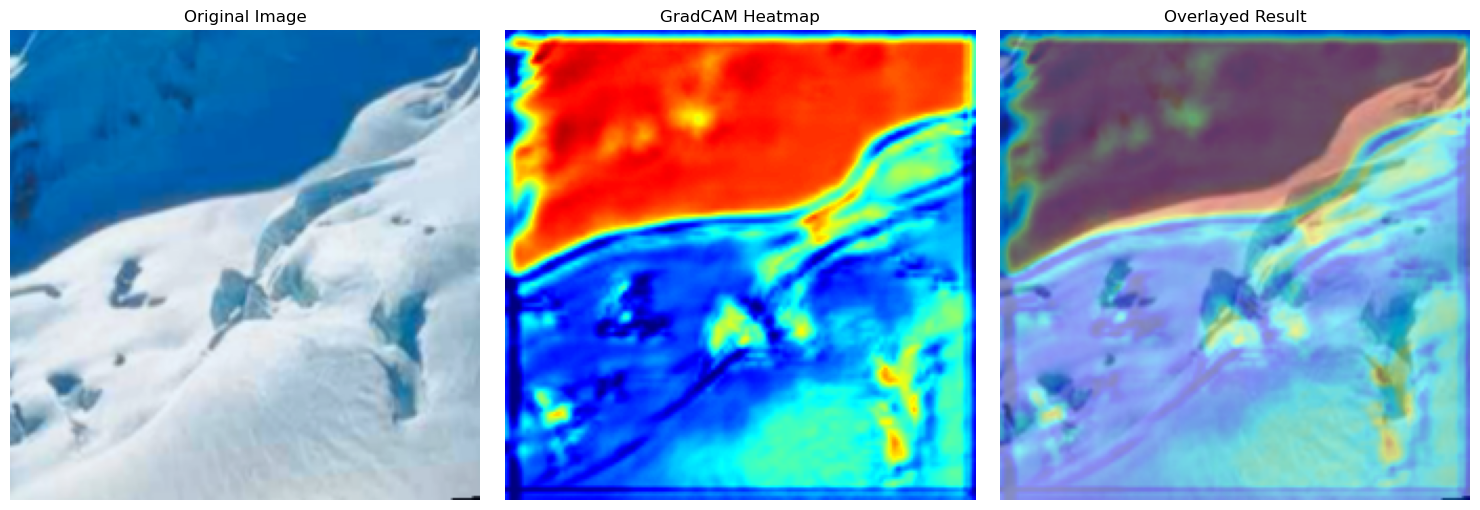

In [ ]:
# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(orig_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(heatmap)
axes[1].set_title('GradCAM Heatmap')
axes[1].axis('off')

axes[2].imshow(overlayed.astype(np.uint8))
axes[2].set_title('Overlayed Result')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# o que ficar claro no final mostrar se acertou
# GRADIENT NAS CAMADAS, o vermelho deveria estar aonde eu quero prever

In [ ]:
class FeatureExtractor:
    """Extract features from a specific layer of a CNN model"""

    def __init__(self, model, layer_name):
        self.model = model
        self.layer_name = layer_name
        self.features = []
        self.hook = None
        self._register_hook()

    def _register_hook(self):
        """Register forward hook to capture layer output"""
        def hook_fn(module, input, output):
            # Flatten spatial dimensions if needed (for conv layers)
            if len(output.shape) > 2:
                # Global average pooling for conv features
                features = torch.mean(output, dim=(2, 3)) if len(output.shape) == 4 else output.flatten(1)
            else:
                features = output
            self.features.append(features.detach().cpu())

        # Find and register hook on the specified layer
        for name, module in self.model.named_modules():
            if name == self.layer_name:
                self.hook = module.register_forward_hook(hook_fn)
                break

        if self.hook is None:
            raise ValueError(f"Layer '{self.layer_name}' not found in model")

    def extract_features(self, dataloader, device='cuda', max_samples=None):
        """Extract features and labels from dataloader"""
        self.model.eval()
        self.features = []
        all_true_labels = []
        all_pred_labels = []

        sample_count = 0

        with torch.no_grad():
            for batch_idx, (images, true_labels) in enumerate(dataloader):
                if max_samples and sample_count >= max_samples:
                    break

                images = images.to(device)
                true_labels = true_labels.to(device)

                # Forward pass to trigger hook
                outputs = self.model(images)
                pred_labels = torch.argmax(outputs, dim=1)

                # Store labels
                all_true_labels.append(true_labels.cpu())
                all_pred_labels.append(pred_labels.cpu())

                sample_count += len(images)

                if (batch_idx + 1) % 10 == 0:
                    print(f"Processed {batch_idx + 1} batches, {sample_count} samples")

        # Concatenate all features and labels
        features = torch.cat(self.features, dim=0).numpy()
        true_labels = torch.cat(all_true_labels, dim=0).numpy()
        pred_labels = torch.cat(all_pred_labels, dim=0).numpy()

        return features, true_labels, pred_labels

    def cleanup(self):
        """Remove the registered hook"""
        if self.hook:
            self.hook.remove()

def project_features_2d(features, method='tsne', **kwargs):
    """
    Project high-dimensional features to 2D using t-SNE or UMAP

    Args:
        features: numpy array of shape (n_samples, n_features)
        method: 'tsne' or 'umap'
        **kwargs: additional parameters for the projection method

    Returns:
        2D projected features of shape (n_samples, 2)
    """
    print(f"Projecting {features.shape[0]} samples with {features.shape[1]} features using {method.upper()}")

    if method.lower() == 'tsne':
        # Default t-SNE parameters
        tsne_params = {
            'n_components': 2,
            'perplexity': 30,
            'learning_rate': 200,
            'max_iter': 1000,
            'random_state': 42
        }
        tsne_params.update(kwargs)

        reducer = TSNE(**tsne_params)
        projected = reducer.fit_transform(features)

    elif method.lower() == 'umap':
        # Default UMAP parameters
        umap_params = {
            'n_components': 2,
            'n_neighbors': 15,
            'min_dist': 0.1,
            'metric': 'euclidean',
            'random_state': 42
        }
        umap_params.update(kwargs)

        reducer = umap.UMAP(**umap_params)
        projected = reducer.fit_transform(features)

    else:
        raise ValueError("Method must be 'tsne' or 'umap'")

    return projected

def plot_2d_projection(projected_features, labels, title="Feature Projection",
                      label_names=None, figsize=(12, 8), save_path=None):
    """
    Plot 2D projection with colored labels

    Args:
        projected_features: 2D array of projected features
        labels: 1D array of labels
        title: plot title
        label_names: list of label names for legend
        figsize: figure size tuple
        save_path: path to save the plot
    """
    plt.figure(figsize=figsize)
  #cada ponto desse e uma imagem, e cada cor dessa e uma classe
    # Create color palette
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    # Plot each class
    for i, label in enumerate(unique_labels):
        mask = labels == label
        label_name = label_names[label] if label_names else f'Class {label}'
        plt.scatter(projected_features[mask, 0], projected_features[mask, 1],
                   c=[colors[i]], label=label_name, alpha=0.7, s=20)

    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

def visualize_cnn_features(model, dataloader, layer_name, device='cuda',
                          method='tsne', use_predicted_labels=False,
                          max_samples=1000, label_names=None, **projection_kwargs):
    """
    Complete pipeline to visualize CNN layer features in 2D

    Args:
        model: pretrained CNN model
        dataloader: dataloader with (image, label) batches
        layer_name: name of the layer to extract features from
        device: computation device
        method: 'tsne' or 'umap'
        use_predicted_labels: if True, use model predictions; if False, use true labels
        max_samples: maximum number of samples to process
        label_names: list of class names for better visualization
        **projection_kwargs: additional parameters for projection method
    """

    # Move model to device
    model = model.to(device)

    # Extract features
    print(f"Extracting features from layer: {layer_name}")
    extractor = FeatureExtractor(model, layer_name)

    try:
        features, true_labels, pred_labels = extractor.extract_features(
            dataloader, device, max_samples
        )

        # Choose labels to use
        labels = pred_labels if use_predicted_labels else true_labels
        label_type = "Predicted" if use_predicted_labels else "True"

        print(f"Feature shape: {features.shape}")
        print(f"Using {label_type.lower()} labels")

        # Project to 2D
        projected = project_features_2d(features, method, **projection_kwargs)

        # Create plot
        title = f"{method.upper()} projection of {layer_name} features ({label_type} Labels)"
        plot_2d_projection(projected, labels, title, label_names)

        # Calculate and display accuracy if using predicted labels
        if use_predicted_labels:
            accuracy = (pred_labels == true_labels).mean()
            print(f"Model accuracy on this subset: {accuracy:.3f}")

        return projected, labels, features

    finally:
        # Clean up
        extractor.cleanup()




se ta separado no Rˆ2 ta separado no RˆN, mas se nao tiver separado no Rˆ2 nao sabemos o que ta acontecendo no RˆN

Extracting features from layer: features.1.0
Feature shape: (107, 256)
Using true labels
Projecting 107 samples with 256 features using TSNE


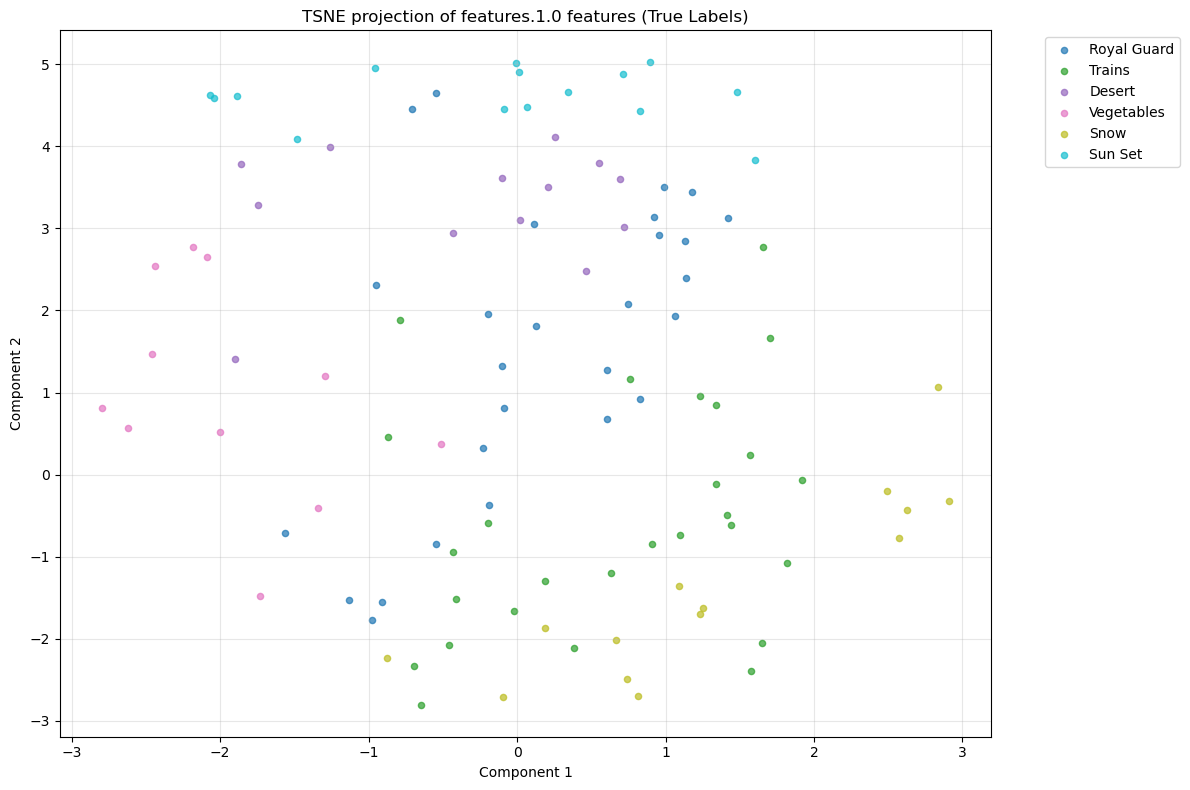

Extracting features from layer: features.1.0
Feature shape: (107, 256)
Using predicted labels
Projecting 107 samples with 256 features using UMAP


/home/afalcao/miniconda3/envs/mo434/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/afalcao/miniconda3/envs/mo434/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


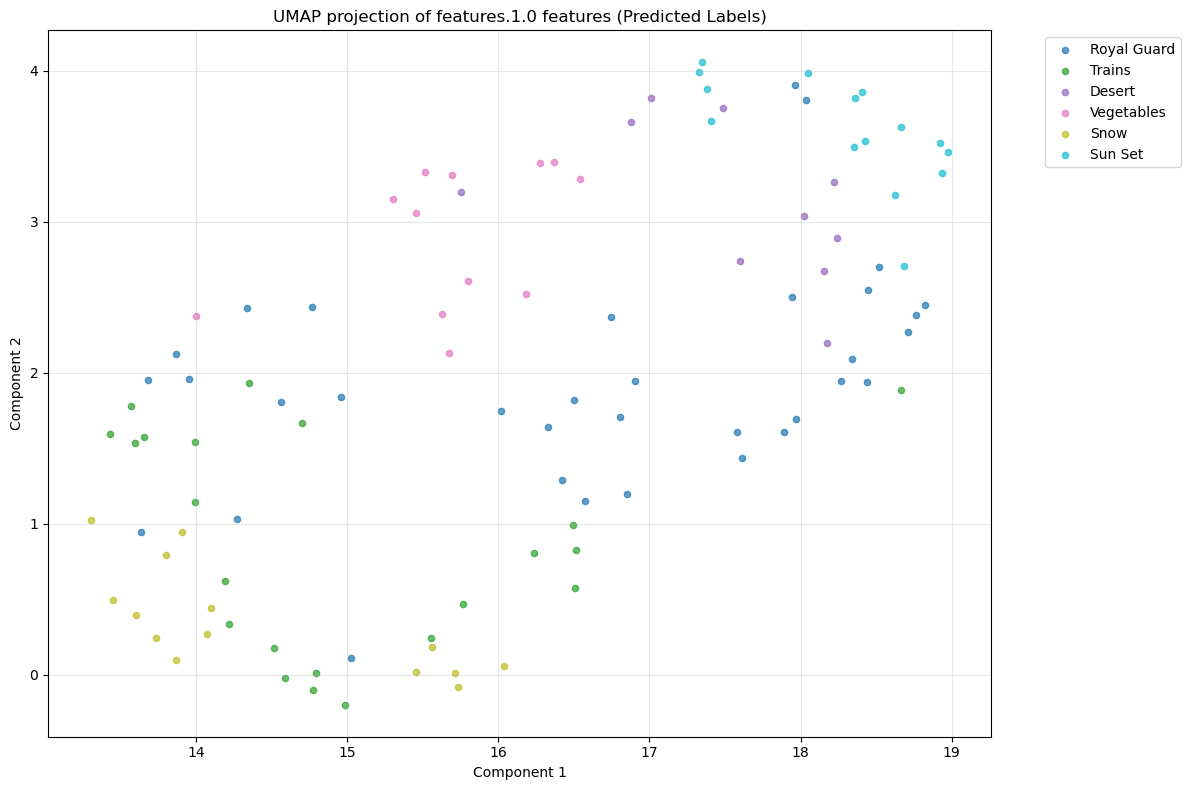

Model accuracy on this subset: 0.897


In [ ]:
#projetando no plano pra ver se acertou
class_names = ['Royal Guard', 'Trains', 'Desert', 'Vegetables', 'Snow', 'Sun Set' ]

# Visualize with t-SNE
projected, labels, features = visualize_cnn_features(
        model=model,
        dataloader=testload,
        layer_name=target_layer_name,
        device=device,
        method='tsne',
        use_predicted_labels=False,
        max_samples=2000,
        label_names=class_names,
        perplexity=50,  # t-SNE parameter
        learning_rate=300
    )

# Visualize with UMAP
projected_umap, _, _ = visualize_cnn_features(
        model=model,
        dataloader=testload,
        layer_name=target_layer_name,
        device=device,
        method='umap',
        use_predicted_labels=True,  # Use model predictions
        max_samples=2000,
        label_names=class_names,
        n_neighbors=20,  # UMAP parameter
        min_dist=0.05
    )